In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from PIL.ImageColor import colormap
from scipy import stats

from ipynb.fs.defs.functions import top_bottom_split_double, find_outliers_iqr

In [2]:
# Einlesen
df = pd.read_csv("../data/processed/master_2024.csv", sep=",", encoding="UTF-8")
df.columns

Index(['Name', 'Typ 1', 'Typ 2', 'ROR', 'erz. Hilfen pro 10000',
       '35a Hilfen pro 10000', 'Überörtlicher Träger', 'Bevölkerung 6 bis 20',
       'Anteil Kinder a.d. Gesamtbev.', 'SGB II-Quote', 'Kinderarztdichte',
       'KJP-Dichte', 'Bildungsindex', 'Bevölkerungsdichte', 'Typ'],
      dtype='object')

In [3]:
df = df[df["Name"] != "Aachen"]

In [5]:
def summary_stats(s):
    desc = s.describe()
    iqr = desc["75%"] - desc["25%"]
    span = desc["max"] - desc["min"]
    cv = desc["std"] / desc["mean"]

    return pd.Series({
        "mean": desc["mean"],
        "median": desc["50%"],
        "std": desc["std"],
        "IQR": iqr,
        "span": span,
        "IQR/span": iqr / span,
        "CV": cv
    })

summary_by_type = (
    df
    .groupby("Typ 2")["35a Hilfen pro 10000"]
    .apply(summary_stats)
    .round(3)
)

print(summary_by_type)

Typ 2                     
Kreis             mean        180.367
                  median      176.000
                  std          62.889
                  IQR          93.250
                  span        232.000
                  IQR/span      0.402
                  CV            0.349
Kreisfreie Stadt  mean        180.591
                  median      165.000
                  std          69.152
                  IQR          71.000
                  span        257.000
                  IQR/span      0.276
                  CV            0.383
Name: 35a Hilfen pro 10000, dtype: float64


In [6]:
top_bottom_split_double(df, "35a Hilfen pro 10000", n=5)

=== Kreise ===

Top 5 (hÃ¶chste Werte):
                          Name  35a Hilfen pro 10000
2            Ennepe-Ruhr-Kreis                   306
1                        Düren                   301
15  Rheinisch-Bergischer Kreis                   265
20                     Viersen                   248
24                   Heinsberg                   248

Bottom 5 (niedrigste Werte):
         Name  35a Hilfen pro 10000
18  Steinfurt                    74
29  Warendorf                    93
4     Herford                    94
0      Borken                   102
22   Coesfeld                   102


=== Kreisfreie StÃ¤dte ===

Top 5 (hÃ¶chste Werte):
                   Name  35a Hilfen pro 10000
43                 Köln                   326
46  Mülheim an der Ruhr                   286
44           Leverkusen                   284
34             Dortmund                   260
47              Münster                   257

Bottom 5 (niedrigste Werte):
               Name  35a Hilfen pro 

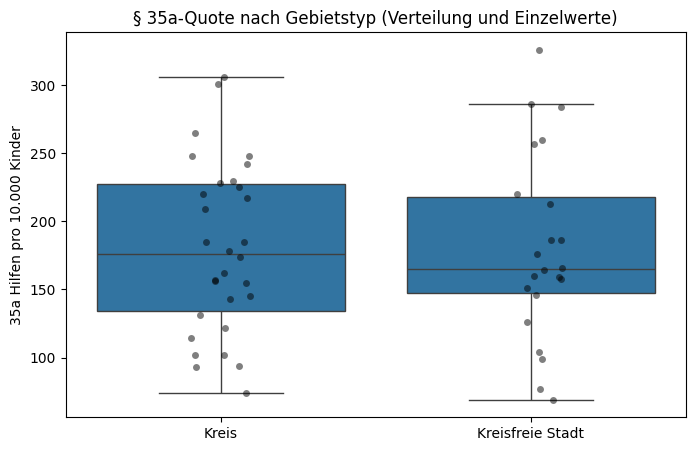

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Typ 2",
    y="35a Hilfen pro 10000",
    showfliers=False
)
sns.stripplot(
    data=df,
    x="Typ 2",
    y="35a Hilfen pro 10000",
    color="black",
    alpha=0.5,
    jitter=True
)
plt.title("§ 35a-Quote nach Gebietstyp (Verteilung und Einzelwerte)")
plt.ylabel("35a Hilfen pro 10.000 Kinder")
plt.xlabel("")
plt.show()


In [18]:
mask_by_type = (
    df
    .groupby("Typ 2")["35a Hilfen pro 10000"]
    .transform(find_outliers_iqr)
)

df.loc[mask_by_type, ["Name", "Typ 2", "35a Hilfen pro 10000"]]



,Name,Typ 2,35a Hilfen pro 10000
43,Köln,Kreisfreie Stadt,326
